# Bank Marketing Campaign Prediction Portfolio Project

This notebook walks through a portfolio-grade end-to-end data science project to predict whether a bank client will subscribe to a term deposit after a tele-marketing campaign.

We cover the full workflow:
- business framing
- data loading and cleaning
- exploratory data analysis
- feature engineering discussion
- baseline and tree-based models
- model evaluation
- error analysis
- model persistence
- MLflow experiment tracking
- FastAPI deployment handoff

> **Target variable**: `y` where `yes` means the client subscribed to a term deposit.


## 1. Business Understanding

Banks use outbound tele-marketing campaigns to sell term deposits. A predictive model can help prioritize which clients are most likely to subscribe, improving campaign efficiency and conversion rates.

### Project objective
Build a binary classification model that predicts whether a client will subscribe to a term deposit.

### Business value
A useful model can help:
- improve campaign targeting
- reduce wasted call volume
- increase conversion efficiency
- support sales planning and resource allocation

### Important modeling note
The feature `duration` is often highly predictive, but it is only fully known after a call takes place. That means:
- if the use case is **post-call analysis**, including `duration` is fine
- if the use case is **pre-call targeting**, `duration` should be excluded

This notebook keeps `duration` in the main baseline because it is part of the canonical dataset, but it explicitly flags this as a deployment consideration.


In [23]:
from google.colab import drive
drive.mount('/content/drive')
directory_path='/content/drive/MyDrive/bank_marketing_mlflow_fastapi'
%cd $directory_path

Mounted at /content/drive
/content/drive/MyDrive/bank_marketing_mlflow_fastapi


In [2]:
# Imports and notebook setup
import warnings
warnings.filterwarnings('ignore')

import json
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from tqdm import tqdm
from IPython.display import display
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)


In [3]:
# Load the Bank Marketing dataset
if 'df_bank' not in globals():
    dataset = fetch_openml(name='bank-marketing', version=1, as_frame=True)
    df_bank = dataset.frame.copy()
    df_bank.columns = [
        'age','job','marital','education','default','balance','housing','loan',
        'contact','day','month','duration','campaign','pdays','previous','poutcome','y'
    ]
    df_bank['y'] = df_bank['y'].astype(str).replace({'1':'no','2':'yes'})

display(df_bank.head())
print(df_bank.shape)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


(45211, 17)


## 2. Data Understanding

We begin with a quick review of the dataset shape, missingness, target balance, and feature types.


In [4]:
# Basic inspection
print(df_bank.info())
print(df_bank.isna().sum().sort_values(ascending=False).head(10))
print(df_bank['y'].value_counts())
print(df_bank['y'].value_counts(normalize=True))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   age        45211 non-null  int64   
 1   job        45211 non-null  category
 2   marital    45211 non-null  category
 3   education  45211 non-null  category
 4   default    45211 non-null  category
 5   balance    45211 non-null  int64   
 6   housing    45211 non-null  category
 7   loan       45211 non-null  category
 8   contact    45211 non-null  category
 9   day        45211 non-null  int64   
 10  month      45211 non-null  category
 11  duration   45211 non-null  int64   
 12  campaign   45211 non-null  int64   
 13  pdays      45211 non-null  int64   
 14  previous   45211 non-null  int64   
 15  poutcome   45211 non-null  category
 16  y          45211 non-null  object  
dtypes: category(9), int64(7), object(1)
memory usage: 3.1+ MB
None
age          0
job          0
marital      0

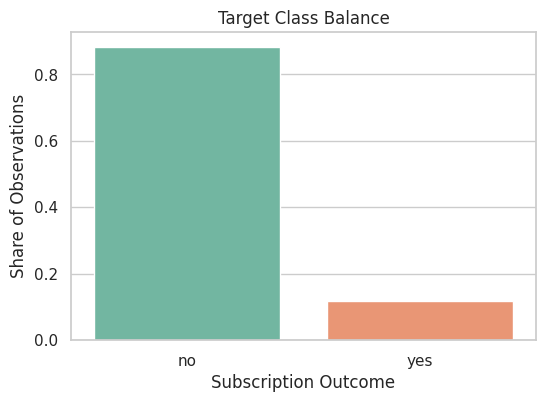

In [5]:
# Visualize class balance
class_balance = df_bank['y'].value_counts(normalize=True).reset_index()
class_balance.columns = ['target', 'share']

plt.figure(figsize=(6, 4))
sns.barplot(data=class_balance, x='target', y='share', hue='target', dodge=False, palette='Set2')
plt.title('Target Class Balance')
plt.xlabel('Subscription Outcome')
plt.ylabel('Share of Observations')
plt.legend([], [], frameon=False)
plt.show()


The target is imbalanced, with `no` dominating the dataset. That means plain accuracy alone is not enough. We should pay close attention to **precision**, **recall**, **F1**, and especially **ROC AUC**.


In [6]:
# Numeric summary
numeric_cols = df_bank.select_dtypes(include=['int64', 'float64']).columns.tolist()
display(df_bank[numeric_cols].describe().T)


,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0


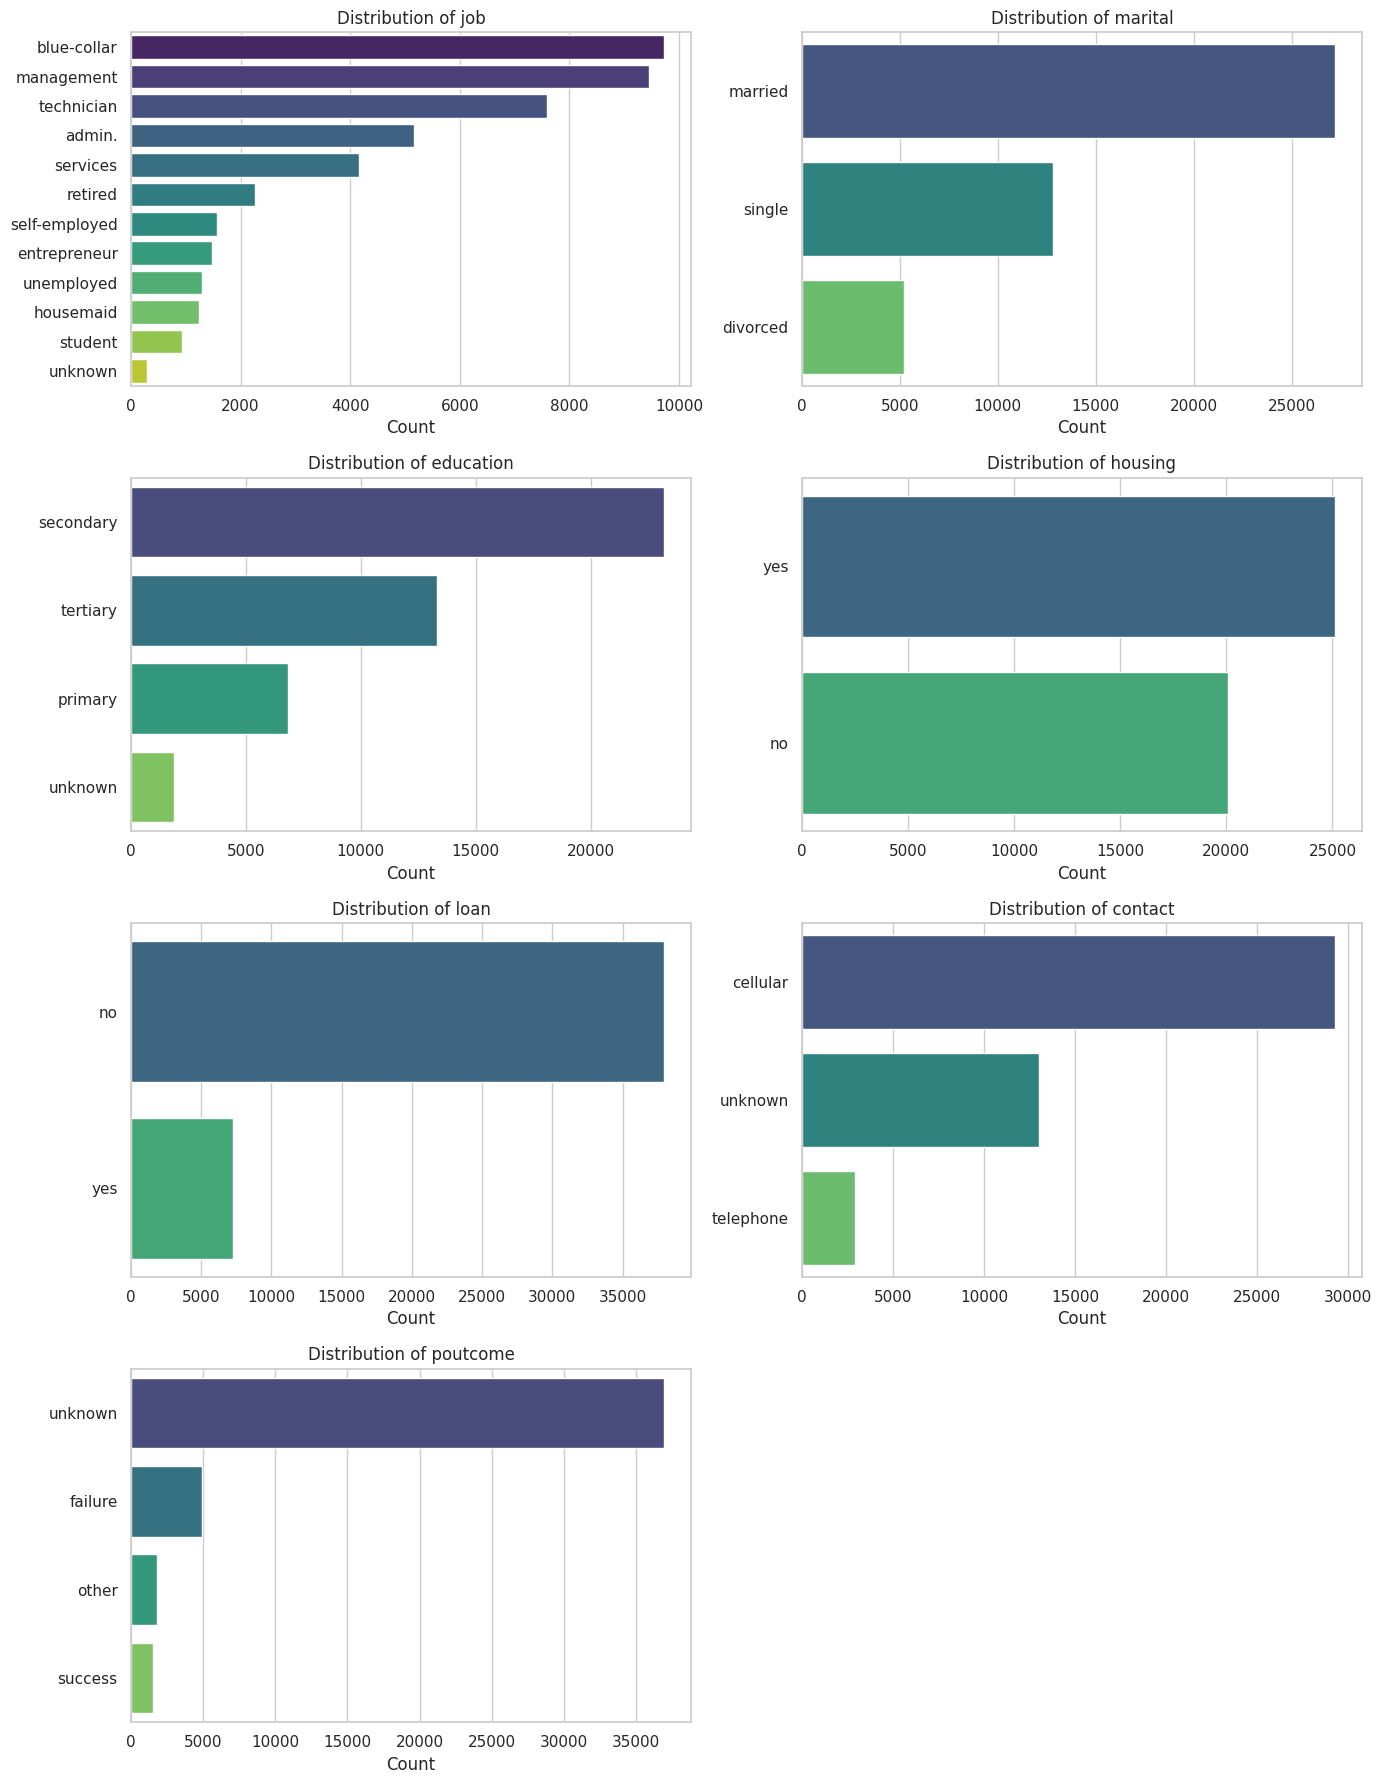

In [7]:
# Explore a few important categorical features
fig_cols = ['job', 'marital', 'education', 'housing', 'loan', 'contact', 'poutcome']
fig, axes = plt.subplots(4, 2, figsize=(14, 18))
axes = axes.flatten()

for idx_val, col_name in enumerate(fig_cols):
    order_vals = df_bank[col_name].value_counts().index
    sns.countplot(data=df_bank, y=col_name, order=order_vals, ax=axes[idx_val], palette='viridis')
    axes[idx_val].set_title('Distribution of ' + col_name)
    axes[idx_val].set_xlabel('Count')
    axes[idx_val].set_ylabel('')

axes[-1].axis('off')
plt.tight_layout()
plt.show()


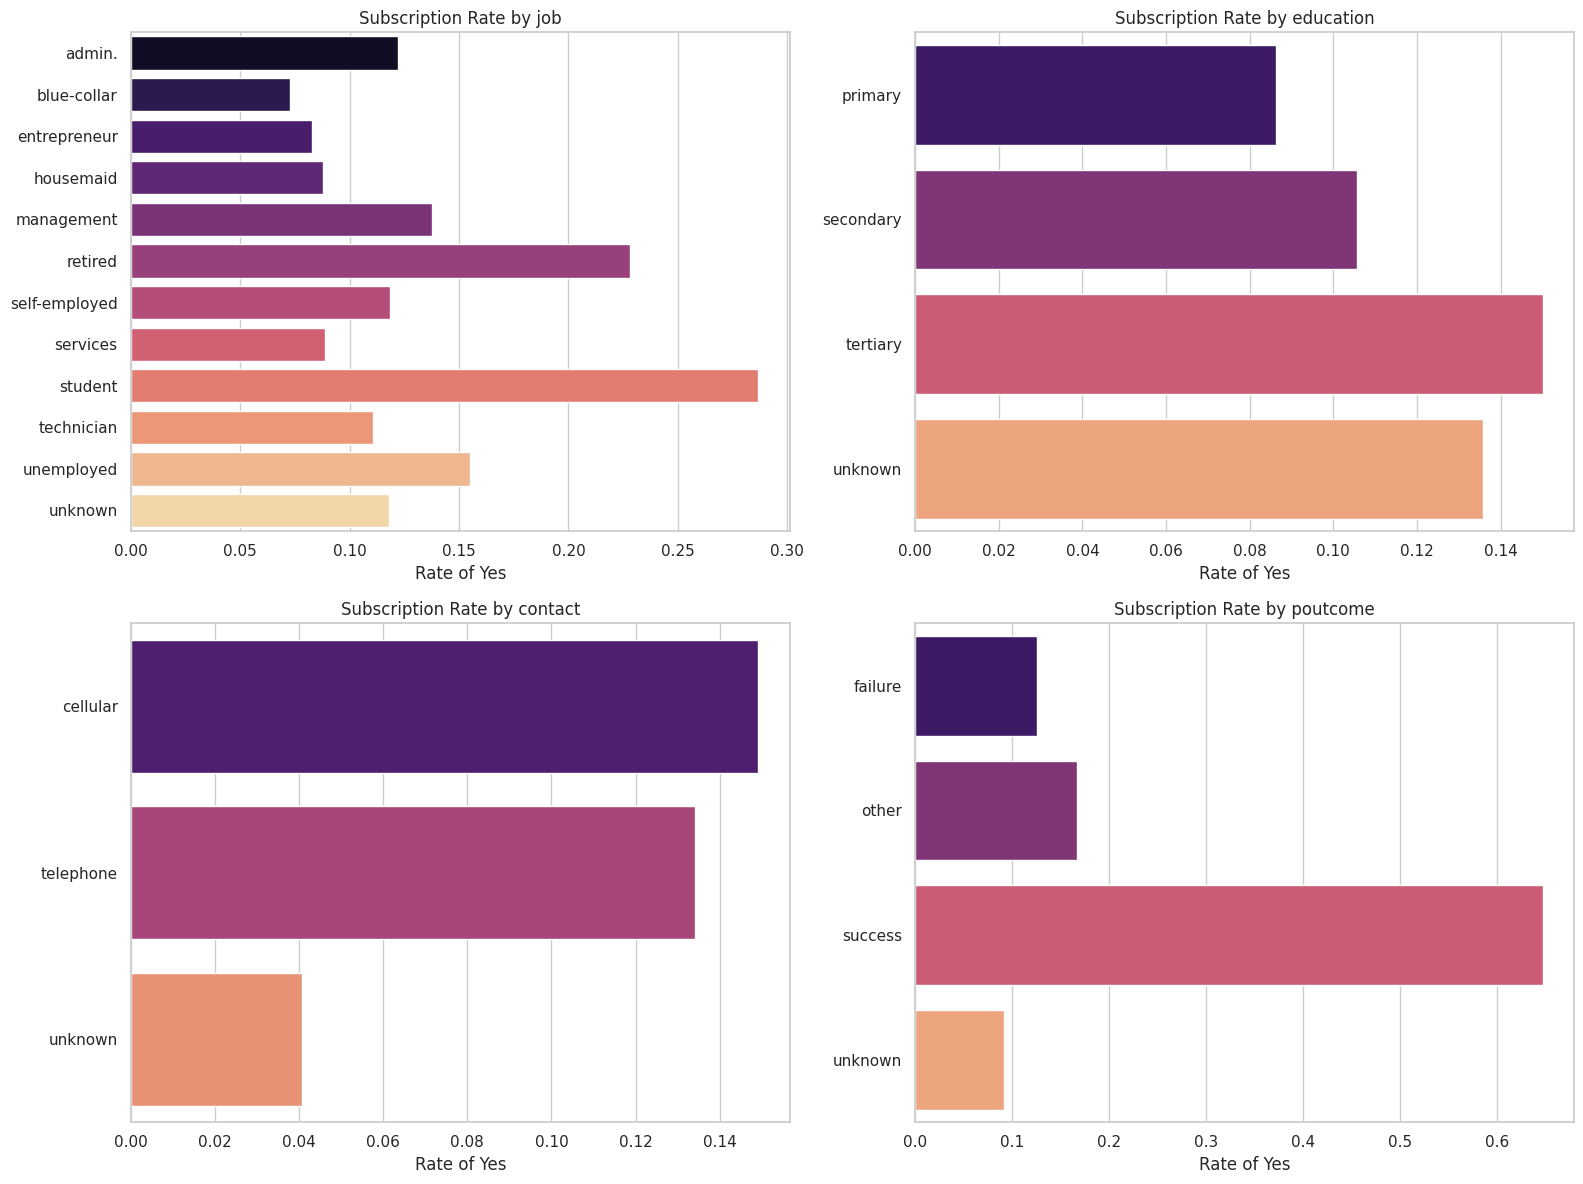

In [8]:
# Subscription rate by selected categories
plot_cols = ['job', 'education', 'contact', 'poutcome']
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx_val, col_name in enumerate(plot_cols):
    rate_df = df_bank.groupby(col_name)['y'].apply(lambda vals: (vals == 'yes').mean()).sort_values(ascending=False).reset_index()
    rate_df.columns = [col_name, 'subscription_rate']
    sns.barplot(data=rate_df, x='subscription_rate', y=col_name, ax=axes[idx_val], palette='magma')
    axes[idx_val].set_title('Subscription Rate by ' + col_name)
    axes[idx_val].set_xlabel('Rate of Yes')
    axes[idx_val].set_ylabel('')

plt.tight_layout()
plt.show()


These plots help identify early patterns. Some client segments and previous campaign outcomes appear much more favorable than others, which is exactly the kind of signal a supervised classifier can use.


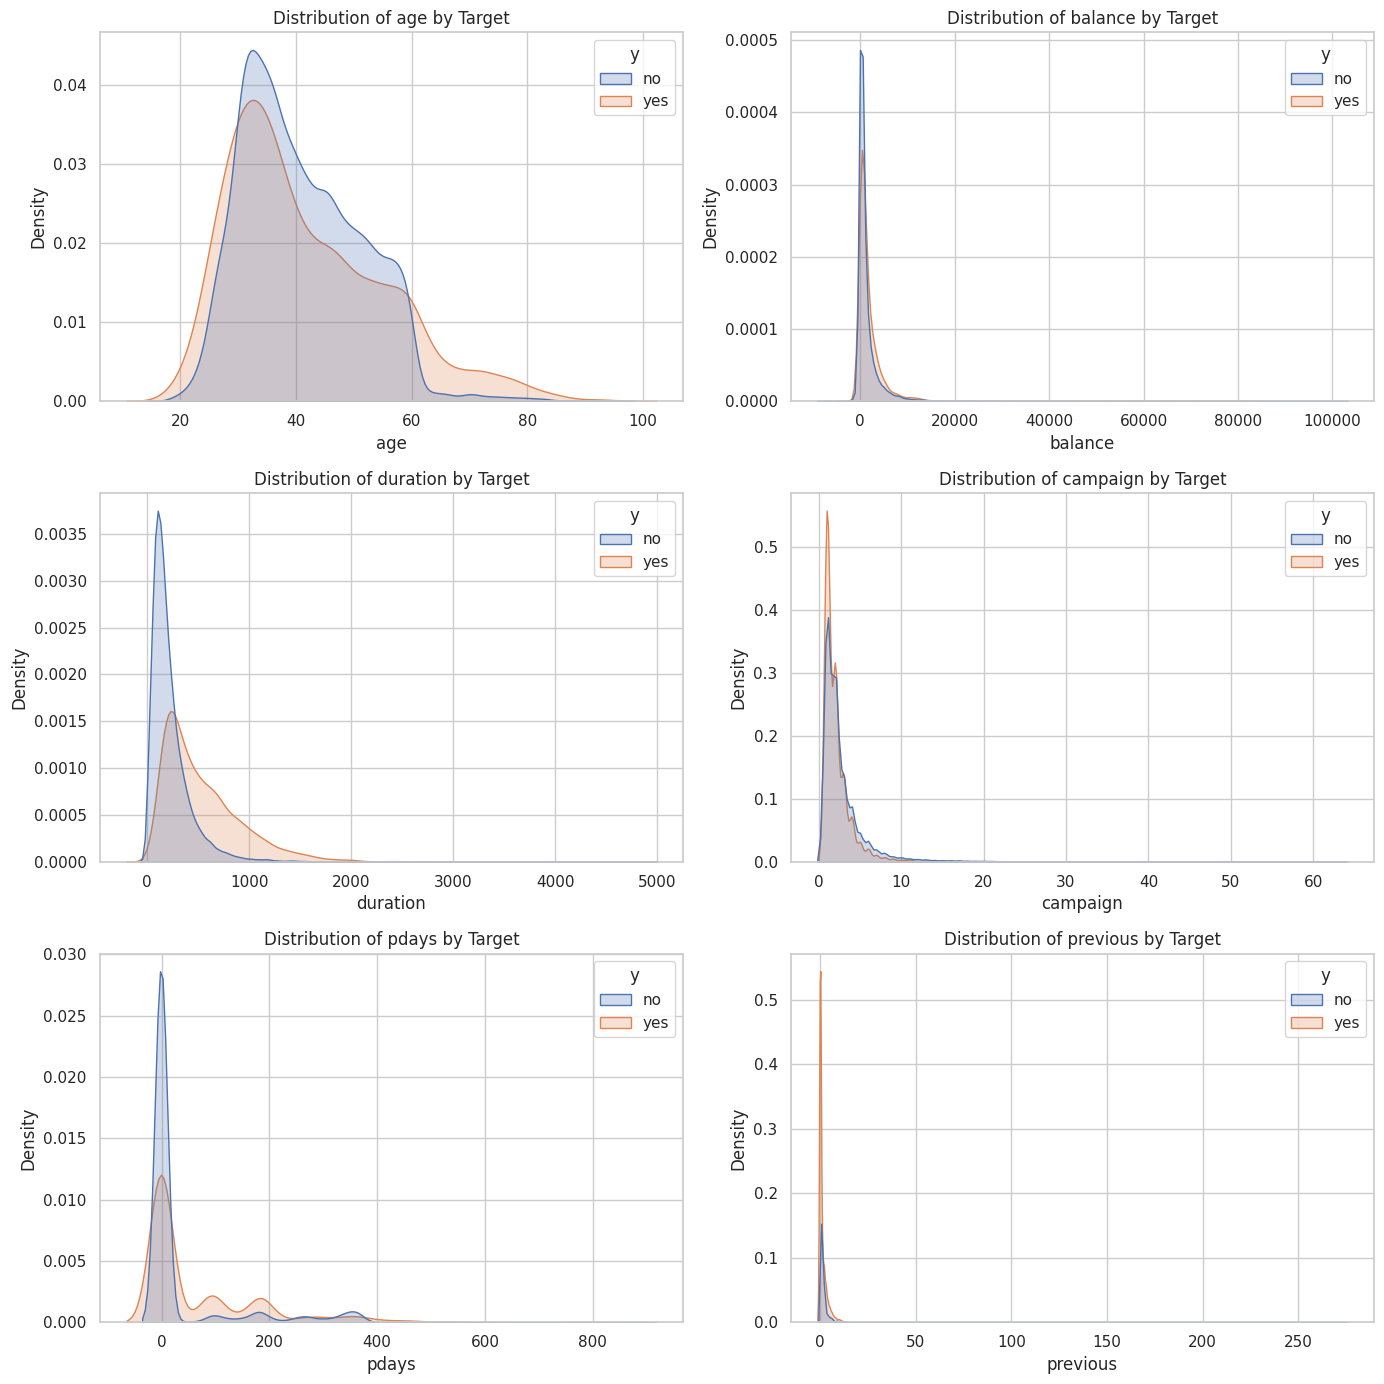

In [9]:
# Numeric distributions by target
plot_numeric = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()

for idx_val, col_name in enumerate(plot_numeric):
    sns.kdeplot(data=df_bank, x=col_name, hue='y', fill=True, common_norm=False, ax=axes[idx_val])
    axes[idx_val].set_title('Distribution of ' + col_name + ' by Target')

plt.tight_layout()
plt.show()


## 3. Data Preparation

We separate features and target, then build a preprocessing pipeline.

### Preprocessing strategy
Numeric variables:
- median imputation
- standardization

Categorical variables:
- most-frequent imputation
- one-hot encoding

This is a solid and portfolio-friendly setup because it is reproducible, deployable, and easy to extend.


In [10]:
# Train-test split and preprocessing setup
X_bank = df_bank.drop(columns=['y']).copy()
y_bank = df_bank['y'].map({'no': 0, 'yes': 1}).astype(int)

numeric_features = X_bank.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_bank.select_dtypes(include=['object', 'category']).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X_bank,
    y_bank,
    test_size=0.2,
    random_state=42,
    stratify=y_bank
)

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

print(X_train.shape)
print(X_test.shape)
print(numeric_features)
print(categorical_features)


(36168, 16)
(9043, 16)
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


## 4. Modeling

We'll compare a few strong baseline models:
- Logistic Regression
- Random Forest
- Gradient Boosting

This gives a mix of interpretable linear modeling and flexible non-linear tree methods.


In [11]:
# Train and evaluate candidate models
model_dict = {
    'logistic_regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'random_forest': RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight='balanced_subsample',
        n_jobs=-1
    ),
    'gradient_boosting': GradientBoostingClassifier(random_state=42)
}

result_rows = []
trained_models = {}

for model_name in tqdm(model_dict, desc='training_models'):
    pipeline_obj = Pipeline([
        ('preprocess', preprocess),
        ('model', model_dict[model_name])
    ])
    pipeline_obj.fit(X_train, y_train)
    pred_vals = pipeline_obj.predict(X_test)
    prob_vals = pipeline_obj.predict_proba(X_test)[:, 1]

    metric_row = {
        'model': model_name,
        'accuracy': accuracy_score(y_test, pred_vals),
        'precision': precision_score(y_test, pred_vals),
        'recall': recall_score(y_test, pred_vals),
        'f1': f1_score(y_test, pred_vals),
        'roc_auc': roc_auc_score(y_test, prob_vals)
    }
    result_rows.append(metric_row)
    trained_models[model_name] = pipeline_obj

results_df = pd.DataFrame(result_rows).sort_values('roc_auc', ascending=False).reset_index(drop=True)
display(results_df)


training_models: 100%|██████████| 3/3 [00:24<00:00,  8.30s/it]


,model,accuracy,precision,recall,f1,roc_auc
0,random_forest,0.904788,0.687619,0.341210,0.456096,0.929093
1,gradient_boosting,0.905452,0.652632,0.410208,0.503772,0.924033
2,logistic_regression,0.845737,0.418244,0.814745,0.552741,0.907922


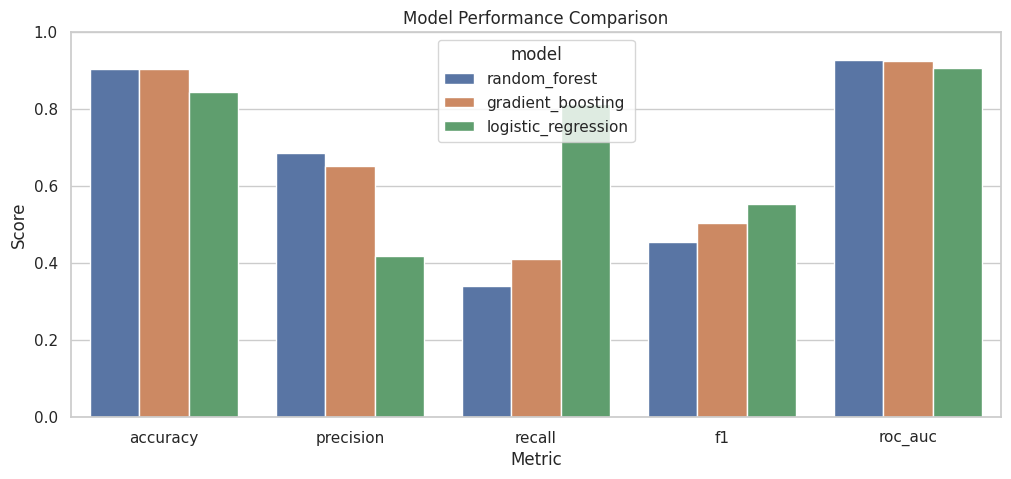

In [12]:
# Visual comparison of model performance
metric_plot = results_df.melt(id_vars='model', value_vars=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'])

plt.figure(figsize=(12, 5))
sns.barplot(data=metric_plot, x='variable', y='value', hue='model')
plt.title('Model Performance Comparison')
plt.xlabel('Metric')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.show()


At this stage, **ROC AUC** is especially useful because it measures ranking quality across thresholds. In campaign targeting, ranking likely subscribers well is often more important than using a single default threshold.


In [13]:
# Select the best model
best_model_name = results_df.iloc[0]['model']
best_pipeline = trained_models[best_model_name]

best_pred = best_pipeline.predict(X_test)
best_prob = best_pipeline.predict_proba(X_test)[:, 1]

print(best_model_name)
print(roc_auc_score(y_test, best_prob))
print(classification_report(y_test, best_pred))


random_forest
0.9290930655659891
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      7985
           1       0.69      0.34      0.46      1058

    accuracy                           0.90      9043
   macro avg       0.80      0.66      0.70      9043
weighted avg       0.89      0.90      0.89      9043



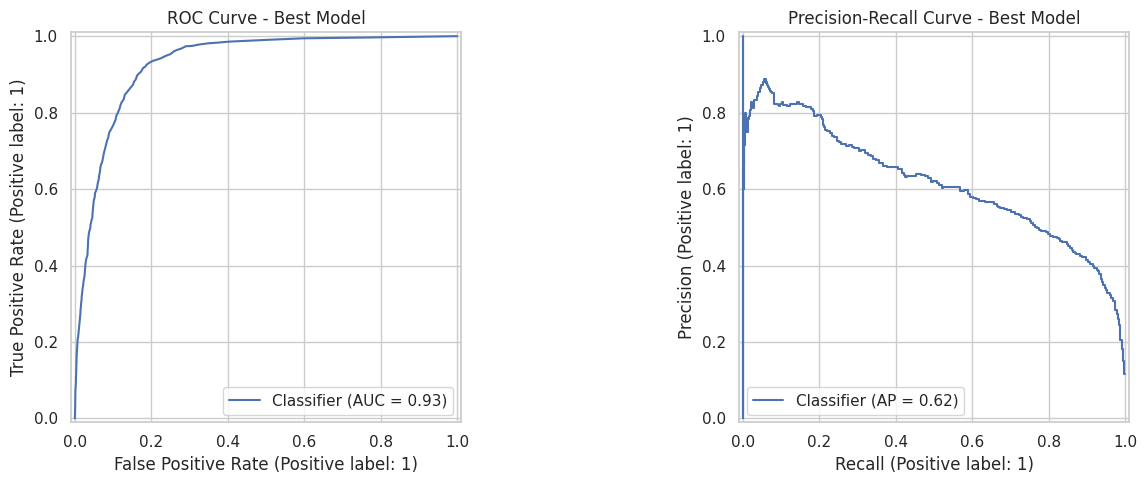

In [14]:
# ROC curve and Precision-Recall curve for the best model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

RocCurveDisplay.from_predictions(y_test, best_prob, ax=axes[0])
axes[0].set_title('ROC Curve - Best Model')

PrecisionRecallDisplay.from_predictions(y_test, best_prob, ax=axes[1])
axes[1].set_title('Precision-Recall Curve - Best Model')

plt.tight_layout()
plt.show()


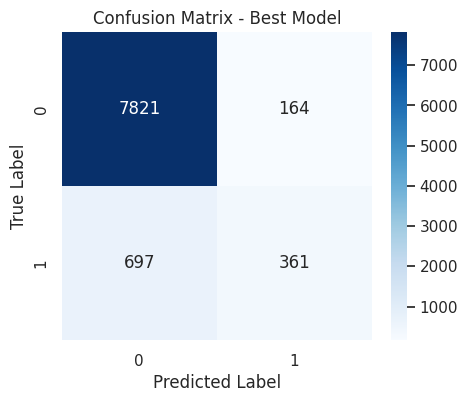

In [15]:
# Confusion matrix
conf_mat = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Best Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


## 5. Cross-Validation

A portfolio-grade project should not rely only on one train-test split. Here we add cross-validation to get a more stable estimate of model performance.


In [16]:
# Cross-validation for the best model choice
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_pipeline, X_bank, y_bank, cv=cv_strategy, scoring='roc_auc', n_jobs=-1)
print(cv_scores)
print(cv_scores.mean())
print(cv_scores.std())


[0.93615096 0.93288184 0.92848463 0.93334963 0.92577511]
0.9313284324981081
0.003706256698344937


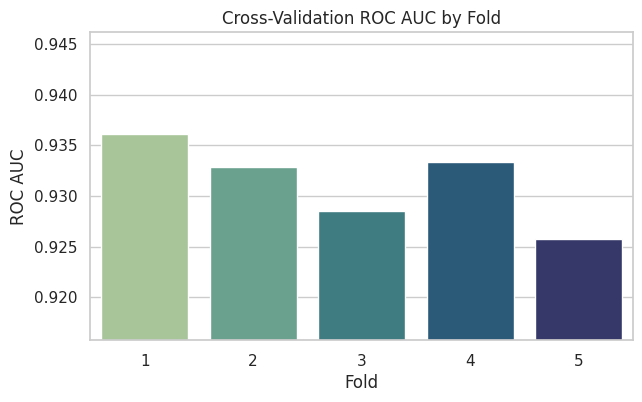

In [17]:
# Plot cross-validation scores
cv_df = pd.DataFrame({'fold': list(range(1, len(cv_scores) + 1)), 'roc_auc': cv_scores})
plt.figure(figsize=(7, 4))
sns.barplot(data=cv_df, x='fold', y='roc_auc', hue='fold', dodge=False, palette='crest')
plt.title('Cross-Validation ROC AUC by Fold')
plt.xlabel('Fold')
plt.ylabel('ROC AUC')
plt.legend([], [], frameon=False)
plt.ylim(cv_df['roc_auc'].min() - 0.01, cv_df['roc_auc'].max() + 0.01)
plt.show()


## 6. Error Analysis and Scored Output

A strong project should leave behind useful artifacts. We generate a scored test set for inspection and downstream review.


In [18]:
# Save scored predictions
portfolio_dir = 'bank_marketing_fastapi_mlflow'
test_output = X_test.copy()
test_output['y_true'] = y_test.values
test_output['y_pred'] = best_pred
test_output['y_score'] = best_prob
display(test_output.head())


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y_true,y_pred,y_score
1392,40,blue-collar,married,primary,no,640,yes,yes,unknown,8,may,347,2,-1,0,unknown,0,0,0.000
7518,44,technician,married,secondary,no,378,yes,no,unknown,30,may,203,2,-1,0,unknown,0,0,0.000
12007,31,services,married,secondary,no,356,yes,no,unknown,20,jun,228,5,-1,0,unknown,0,0,0.010
5536,36,blue-collar,married,primary,no,655,yes,no,unknown,23,may,153,4,-1,0,unknown,0,0,0.000
29816,34,services,single,secondary,no,1921,yes,no,cellular,4,feb,61,1,-1,0,unknown,0,0,0.015


In [19]:
# Inspect likely false positives and false negatives
false_positive_df = test_output[(test_output['y_true'] == 0) & (test_output['y_pred'] == 1)].sort_values('y_score', ascending=False)
false_negative_df = test_output[(test_output['y_true'] == 1) & (test_output['y_pred'] == 0)].sort_values('y_score', ascending=True)

display(false_positive_df.head(10))
display(false_negative_df.head(10))


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y_true,y_pred,y_score
40628,47,management,married,tertiary,no,699,no,no,cellular,5,aug,432,3,97,2,success,0,1,0.950
44200,60,services,single,secondary,no,739,no,no,cellular,15,jul,261,1,182,1,success,0,1,0.915
44028,39,management,married,tertiary,no,2939,no,no,cellular,29,jun,385,1,165,2,success,0,1,0.890
42577,32,services,married,secondary,no,914,no,no,cellular,29,dec,434,1,197,1,success,0,1,0.880
43135,25,student,single,secondary,no,469,no,no,cellular,24,feb,524,1,187,2,success,0,1,0.880
43423,80,retired,married,secondary,no,8304,no,no,telephone,6,apr,681,1,118,11,success,0,1,0.845
44777,62,admin.,married,secondary,no,4608,no,no,cellular,14,sep,706,1,186,1,success,0,1,0.840
31791,38,technician,married,tertiary,no,3234,no,no,cellular,8,apr,281,1,141,2,success,0,1,0.825
42717,61,management,married,tertiary,no,13546,no,no,cellular,25,jan,318,2,283,3,success,0,1,0.790
40607,46,self-employed,single,secondary,no,526,no,no,cellular,4,aug,326,1,96,3,success,0,1,0.780


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y_true,y_pred,y_score
41070,45,management,married,tertiary,no,2671,no,no,cellular,14,aug,94,4,-1,0,unknown,1,0,0.000
4455,31,blue-collar,married,secondary,no,2,yes,no,unknown,20,may,182,2,-1,0,unknown,1,0,0.000
13807,47,blue-collar,married,secondary,no,182,yes,no,telephone,10,jul,39,1,-1,0,unknown,1,0,0.000
16471,27,technician,married,secondary,no,-392,yes,no,cellular,23,jul,228,2,-1,0,unknown,1,0,0.000
22255,55,blue-collar,married,secondary,no,196,no,no,cellular,21,aug,81,1,-1,0,unknown,1,0,0.005
35820,36,management,married,tertiary,no,0,yes,no,cellular,8,may,308,3,-1,0,unknown,1,0,0.005
33493,32,management,single,tertiary,no,819,yes,no,cellular,20,apr,114,2,-1,0,unknown,1,0,0.010
9011,36,blue-collar,married,secondary,no,1772,no,no,unknown,5,jun,208,1,-1,0,unknown,1,0,0.010
19757,41,technician,married,tertiary,no,1517,no,no,cellular,8,aug,193,3,-1,0,unknown,1,0,0.010
43874,51,management,married,tertiary,no,0,no,no,unknown,7,jun,302,1,-1,0,unknown,1,0,0.010


## 7. Model Persistence

We save the best model as a serialized pipeline so it can be used directly by an API.


In [25]:
import os

# Save model and metadata
model_path = os.path.join(directory_path, 'models', 'bank_marketing_model.joblib')
metadata_path = os.path.join(directory_path, 'models', 'model_metadata.json')

joblib.dump(best_pipeline, model_path)
metadata_obj = {
    'best_model_name': best_model_name,
    'numeric_features': numeric_features,
    'categorical_features': categorical_features,
    'target_mapping': {'no': 0, 'yes': 1}
}
with open(metadata_path, 'w') as file_obj:
    json.dump(metadata_obj, file_obj, indent=2)

print(model_path)
print(metadata_path)

/content/drive/MyDrive/bank_marketing_mlflow_fastapi/models/bank_marketing_model.joblib
/content/drive/MyDrive/bank_marketing_mlflow_fastapi/models/model_metadata.json


## 8. MLflow for MLOps

MLflow helps track experiments, metrics, parameters, and model artifacts.

The code below is notebook-friendly and can be run locally if MLflow is installed.


In [29]:
%%capture
!pip install mlflow

In [37]:
# Optional MLflow logging
import mlflow
import mlflow.sklearn
import numpy as np
from sklearn.compose import _column_transformer

mlflow.set_experiment('bank_marketing_campaign_prediction')

with mlflow.start_run(run_name=best_model_name + '_notebook_run'):
    mlflow.log_param('model_name', best_model_name)
    mlflow.log_param('test_size', 0.2)
    mlflow.log_metric('accuracy', accuracy_score(y_test, best_pred))
    mlflow.log_metric('precision', precision_score(y_test, best_pred))
    mlflow.log_metric('recall', recall_score(y_test, best_pred))
    mlflow.log_metric('f1', f1_score(y_test, best_pred))
    mlflow.log_metric('roc_auc', roc_auc_score(y_test, best_prob))

    # Using 'name' instead of 'artifact_path' to address deprecation warning
    mlflow.sklearn.log_model(
        best_pipeline,
        name='model',
        skops_trusted_types=[
            'numpy.dtype',
            'sklearn.compose._column_transformer._RemainderColsList'
        ]
    )

print('MLflow run logged')

MLflow run logged


## 9. FastAPI Deployment Handoff

At deployment time, the serialized pipeline can be loaded directly inside a FastAPI app.

Typical inference flow:
1. receive JSON payload
2. convert payload to a one-row pandas DataFrame
3. call `predict` and `predict_proba`
4. return label and probability

A production API was scaffolded separately in `app.py`.


In [38]:
# Example payload for FastAPI testing
sample_payload = {
    'age': 35,
    'job': 'technician',
    'marital': 'single',
    'education': 'tertiary',
    'default': 'no',
    'balance': 1200,
    'housing': 'yes',
    'loan': 'no',
    'contact': 'cellular',
    'day': 12,
    'month': 'may',
    'duration': 180,
    'campaign': 2,
    'pdays': -1,
    'previous': 0,
    'poutcome': 'unknown'
}

sample_df = pd.DataFrame([sample_payload])
sample_pred = best_pipeline.predict(sample_df)[0]
sample_prob = best_pipeline.predict_proba(sample_df)[:, 1][0]

print(sample_pred)
print(sample_prob)


0
0.015


## 10. Final Recommendations

This project is already strong enough for a portfolio because it includes:
- business framing
- reproducible preprocessing
- multiple baseline models
- evaluation beyond accuracy
- visualization
- cross-validation
- saved artifacts
- MLOps tracking with MLflow
- deployment handoff with FastAPI

### Best next improvements
A truly production-ready next version would add:
- threshold tuning based on campaign cost and conversion value
- a pre-call model without `duration`
- feature importance or SHAP explainability
- automated tests for the API
- Docker packaging and CI/CD
- drift monitoring in production
